# Handling categorical missing data

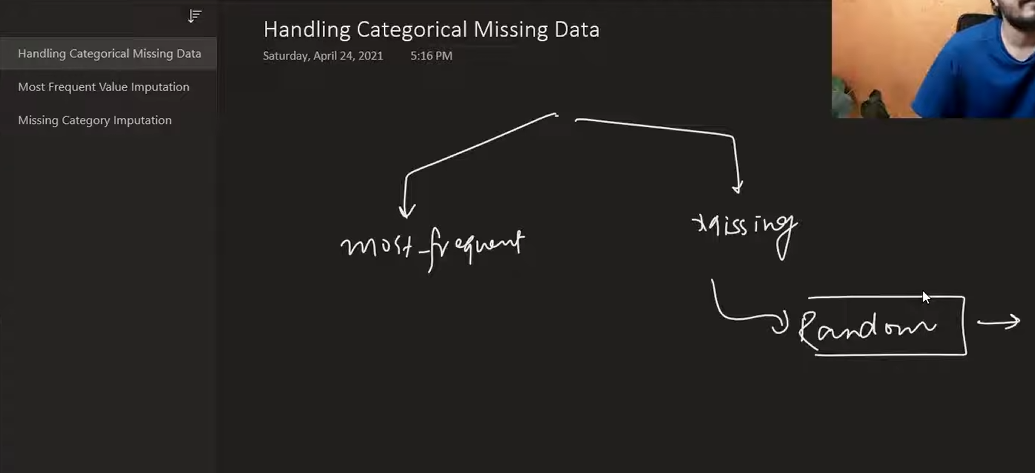

# Most frequent value imputation

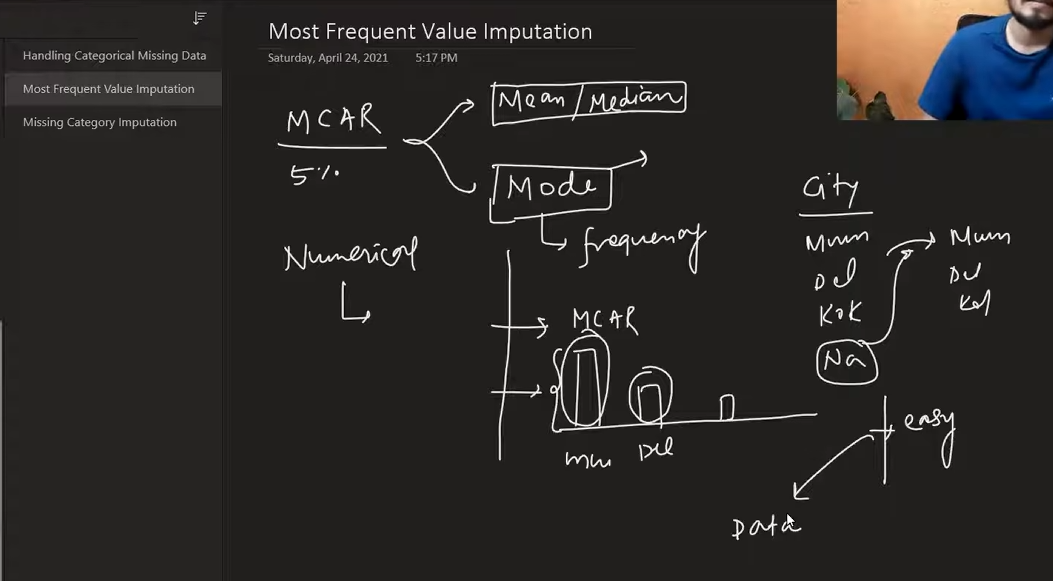
mode should come more time then all the data

advantage :
easy to use

disadvantage:
it changes distribution of data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('trainModified.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [12]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [14]:
df.isnull().mean()


FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

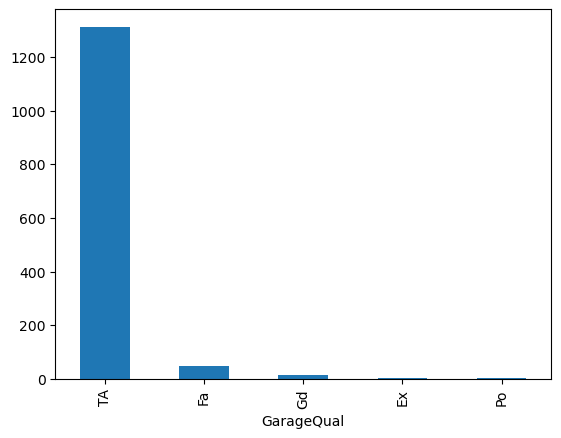

In [15]:
df['GarageQual'].value_counts().plot(kind = 'bar')

In [17]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

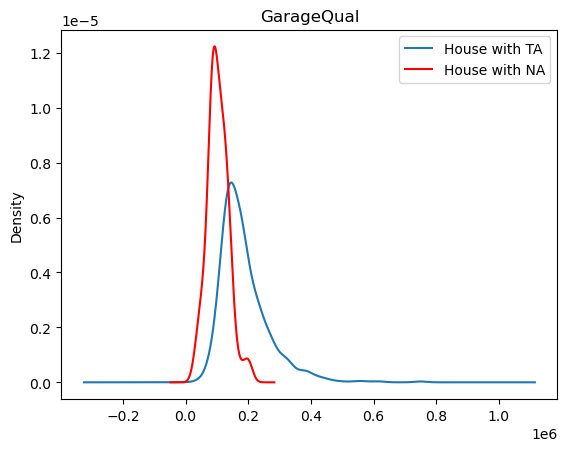

In [22]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind = 'kde',ax = ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind = 'kde',ax = ax,color= 'red')


lines, labels = ax.get_legend_handles_labels()
labels =['House with TA','House with NA']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')


In [27]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [30]:
df['GarageQual'].fillna('TA', inplace = True)

<Axes: xlabel='GarageQual'>

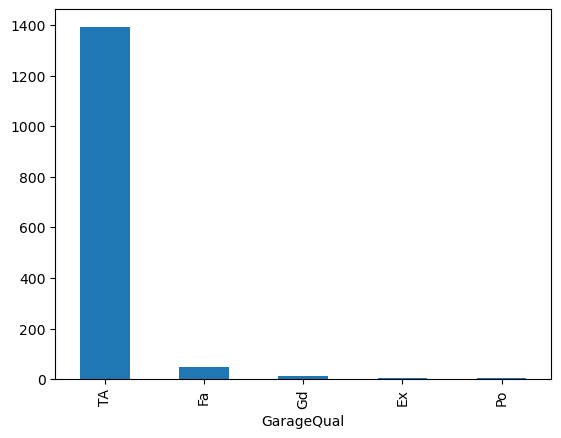

In [31]:
df['GarageQual'].value_counts().plot(kind = 'bar')

Text(0.5, 1.0, 'GarageQual')

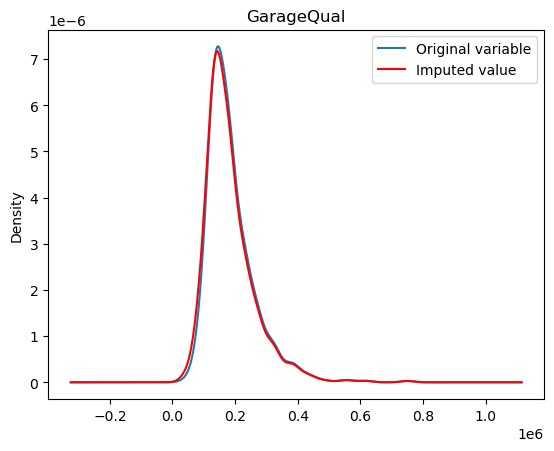

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind ='kde',ax=ax)

    # distribution of the variable after imputation

df[df['GarageQual']=='TA']['SalePrice'].plot(kind = 'kde',ax = ax,color='red')


lines, labels = ax.get_legend_handles_labels()
labels =['Original variable','Imputed value']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')

plt.title('GarageQual')


<Axes: xlabel='FireplaceQu'>

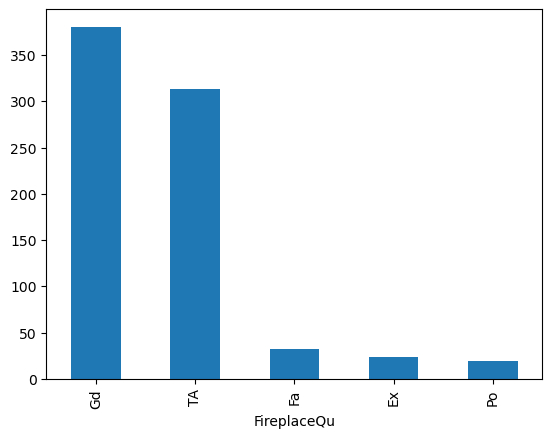

In [37]:
df['FireplaceQu'].value_counts().plot(kind = 'bar')

In [38]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'GarageQual')

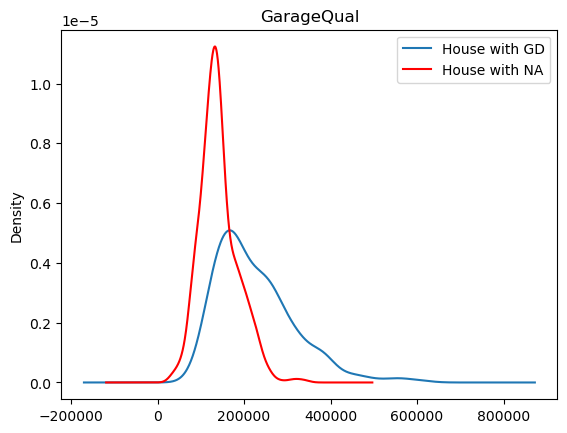

In [40]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind = 'kde',ax = ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind = 'kde',ax = ax,color= 'red')


lines, labels = ax.get_legend_handles_labels()
labels =['House with GD','House with NA']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')


In [41]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']

In [42]:
df['FireplaceQu'].fillna('Gd',inplace = True)

C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_19560\1717838160.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd',inplace = True)


<Axes: xlabel='FireplaceQu'>

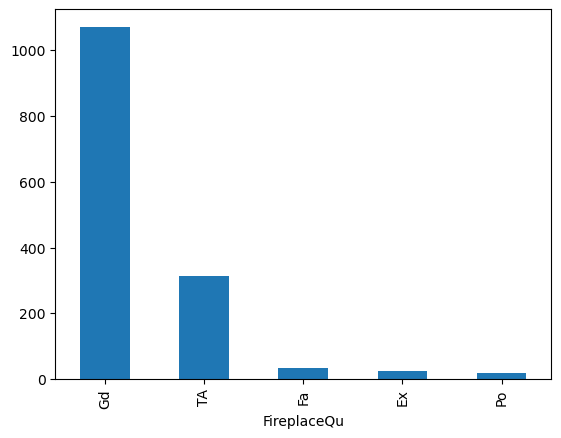

In [43]:
df['FireplaceQu'].value_counts().plot(kind = 'bar')

Text(0.5, 1.0, 'FireplaceQu')

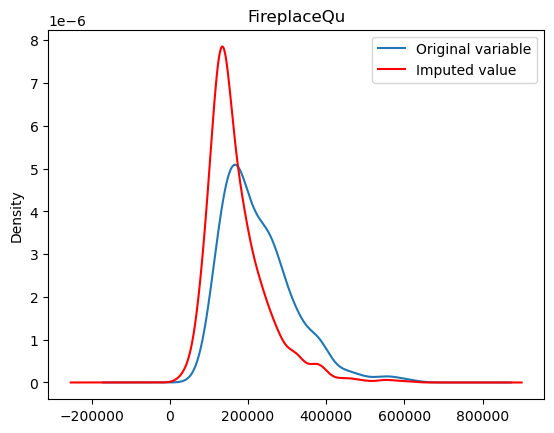

In [44]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind ='kde',ax=ax)

    # distribution of the variable after imputation

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind = 'kde',ax = ax,color='red')


lines, labels = ax.get_legend_handles_labels()
labels =['Original variable','Imputed value']
ax.legend(lines,labels,loc='best')

plt.title('FireplaceQu')


# Using Sklearn

In [51]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns =['SalePrice']),df['SalePrice'],test_size = 0.2)

In [52]:
from sklearn.impute import SimpleImputer

In [56]:
imputer = SimpleImputer(strategy = 'most_frequent')

In [57]:
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [59]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

# Missing category imputation 

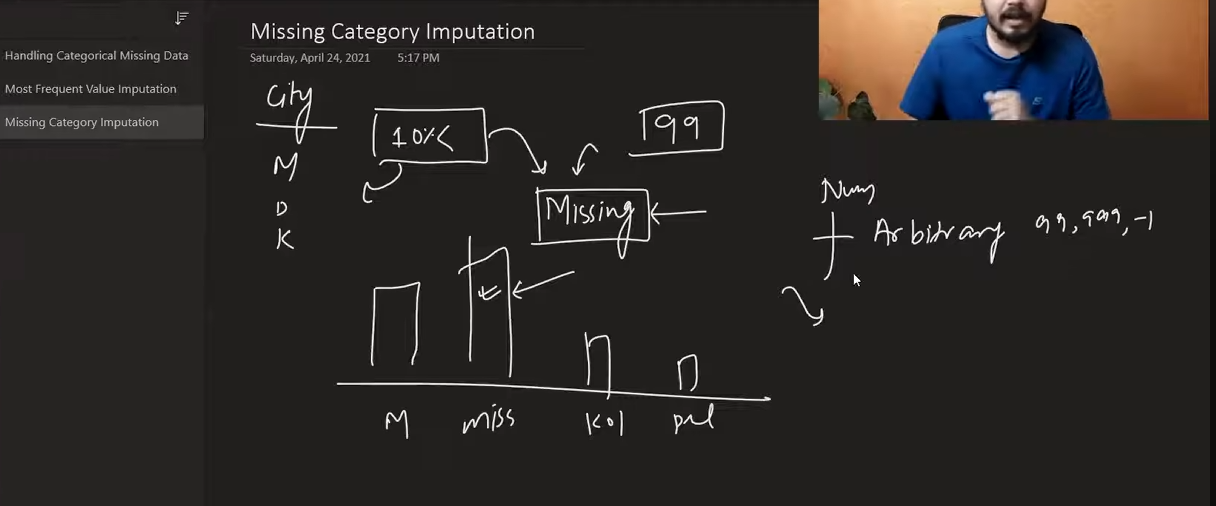
if missing data > 10 % then we don't use mode it will give us

wrong data so instead of this we use  'missing value'  name

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [62]:
df = pd.read_csv('trainModified.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])


In [63]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

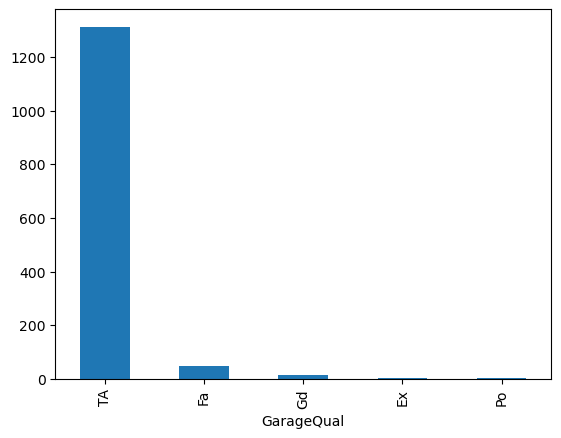

In [65]:
df['GarageQual'].value_counts().sort_values(ascending = False).plot.bar()

In [66]:
df['GarageQual'].fillna('Missing', inplace=True)

C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_19560\4070582888.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('Missing', inplace=True)


Text(0, 0.5, 'Number of houses')

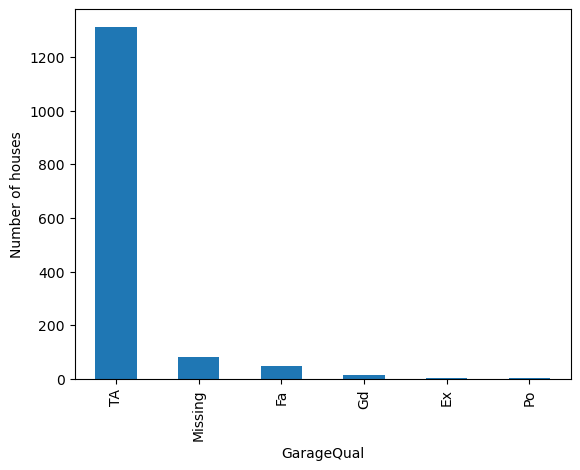

In [71]:
df['GarageQual'].value_counts().sort_values(ascending = False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

In [68]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns =['SalePrice']),df['SalePrice'],test_size = 0.2)

In [70]:
from sklearn.impute import SimpleImputer

In [72]:
imputer = SimpleImputer(strategy = 'constant',fill_value='Missing')

In [73]:
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [74]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)